# Cancer Death Rate Prediction

Predicting cancer death rates across US counties using socioeconomic, demographic and healthcare features from the Cancer Registry dataset.

**Target Variable:** `target_deathrate` — cancer deaths per 100,000 people per county

**Best R2 Score achieved: 0.513 (Random Forest)**

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
cancer_df = pd.read_csv('cancer_reg.csv')

In [3]:
cancer_df

,avganncount,avgdeathsperyear,target_deathrate,incidencerate,medincome,popest2015,povertypercent,studypercap,binnedinc,medianage,...,pctprivatecoveragealone,pctempprivcoverage,pctpubliccoverage,pctpubliccoveragealone,pctwhite,pctblack,pctasian,pctotherrace,pctmarriedhouseholds,birthrate
0,1397.000000,469,164.9,489.800000,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.000000,70,161.3,411.600000,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.000000,50,174.7,349.700000,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.000000,202,194.8,430.400000,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.000000,26,144.4,350.100000,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3042,1962.667684,15,149.6,453.549422,46961,6343,12.4,0.000000,"(45201, 48021.6]",44.2,...,54.9,44.6,31.7,13.2,90.280811,3.837754,0.327613,1.700468,51.063830,7.773512
3043,1962.667684,43,150.1,453.549422,48609,37118,18.8,377.175494,"(48021.6, 51046.4]",30.4,...,53.3,48.6,28.8,17.7,75.706245,2.326771,4.044920,14.130288,52.007937,8.186470
3044,1962.667684,46,153.9,453.549422,51144,34536,15.0,1968.959926,"(51046.4, 54545.6]",30.9,...,52.6,47.8,26.6,16.8,87.961629,2.313188,1.316472,5.680705,55.153949,7.809192
3045,1962.667684,52,175.0,453.549422,50745,25609,13.3,0.000000,"(48021.6, 51046.4]",39.0,...,56.3,49.6,29.5,14.0,92.905681,1.176562,0.244632,2.131790,58.484232,7.582938


## Exploratory Data Analysis

Examining dataset shape, data types and missing values before any preprocessing.

In [4]:
cancer_df.dtypes

avganncount                float64
avgdeathsperyear             int64
target_deathrate           float64
incidencerate              float64
medincome                    int64
popest2015                   int64
povertypercent             float64
studypercap                float64
binnedinc                   object
medianage                  float64
medianagemale              float64
medianagefemale            float64
geography                   object
percentmarried             float64
pctnohs18_24               float64
pcths18_24                 float64
pctsomecol18_24            float64
pctbachdeg18_24            float64
pcths25_over               float64
pctbachdeg25_over          float64
pctemployed16_over         float64
pctunemployed16_over       float64
pctprivatecoverage         float64
pctprivatecoveragealone    float64
pctempprivcoverage         float64
pctpubliccoverage          float64
pctpubliccoveragealone     float64
pctwhite                   float64
pctblack            

In [5]:
cancer_df.shape

(3047, 33)

## Missing Value Analysis

Identifying columns with missing values and their percentages to decide whether to drop or fill them.

In [6]:
cancer_df.isnull().sum()

avganncount                   0
avgdeathsperyear              0
target_deathrate              0
incidencerate                 0
medincome                     0
popest2015                    0
povertypercent                0
studypercap                   0
binnedinc                     0
medianage                     0
medianagemale                 0
medianagefemale               0
geography                     0
percentmarried                0
pctnohs18_24                  0
pcths18_24                    0
pctsomecol18_24            2285
pctbachdeg18_24               0
pcths25_over                  0
pctbachdeg25_over             0
pctemployed16_over          152
pctunemployed16_over          0
pctprivatecoverage            0
pctprivatecoveragealone     609
pctempprivcoverage            0
pctpubliccoverage             0
pctpubliccoveragealone        0
pctwhite                      0
pctblack                      0
pctasian                      0
pctotherrace                  0
pctmarri

In [7]:
missing = cancer_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = False)
print(missing)

pctsomecol18_24            2285
pctprivatecoveragealone     609
pctemployed16_over          152
dtype: int64


In [8]:
missing = (cancer_df.isnull().sum() / len(cancer_df)) * 100
missing = missing[missing > 0].sort_values(ascending = False)
print(missing)

pctsomecol18_24            74.991795
pctprivatecoveragealone    19.986872
pctemployed16_over          4.988513
dtype: float64


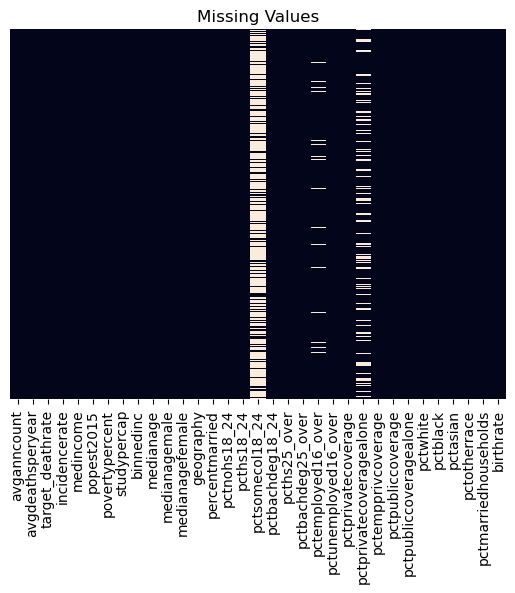

In [9]:
sns.heatmap(cancer_df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values')
plt.show()

## Data Preprocessing

Dropping columns with excessive missing values, filling remaining nulls and encoding categorical variables.

- `pctsomecol18_24` dropped — 75% missing, not recoverable
- `avgdeathsperyear` and `avganncount` dropped — data leakage risk, too directly related to target
- `geography` dropped — county names, too many unique values to encode meaningfully
- Numerical missing values filled with median
- Categorical missing values filled with mode

In [10]:
cancer_df = cancer_df.drop(columns = 'pctsomecol18_24')

In [11]:
missing = (cancer_df.isnull().sum() / len(cancer_df)) * 100
missing = missing[missing > 0].sort_values(ascending = False)
print(missing)

pctprivatecoveragealone    19.986872
pctemployed16_over          4.988513
dtype: float64


In [12]:
for col in cancer_df.select_dtypes(include='object').columns:
    cancer_df[col] = cancer_df[col].fillna(cancer_df[col].mode()[0])

In [13]:
cancer_df.isnull().sum().sum()

np.int64(761)

In [14]:
missing = cancer_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = False)
print(missing)

pctprivatecoveragealone    609
pctemployed16_over         152
dtype: int64


In [15]:
cancer_df.fillna(cancer_df.median(numeric_only=True), inplace=True)
print(cancer_df.isnull().sum().sum())

0


## Feature and Target Separation

In [16]:
x = cancer_df.drop(columns = ['target_deathrate', 'geography', 'avgdeathsperyear',
                             'avganncount'], axis = 1)
y = cancer_df['target_deathrate']

## Encoding Categorical Variables

In [17]:
x = pd.get_dummies(x, drop_first=True)

## Train Test Split

In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

## Feature Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [20]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Model 1 — Linear Regression

Baseline model using Linear Regression with 10-fold cross validation.

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
regression = LinearRegression().fit(x_train, y_train)
mse = cross_val_score(regression, x_train, y_train, scoring='neg_mean_squared_error', cv=10)

In [22]:
mse

array([-318.69854386, -384.74798731, -319.58807522, -358.6357683 ,
       -381.30186823, -398.31041429, -395.60890913, -324.52173066,
       -324.9216479 , -404.16293019])

In [23]:
np.mean(mse)

np.float64(-361.049787508029)

In [24]:
reg_pred = regression.predict(x_test)

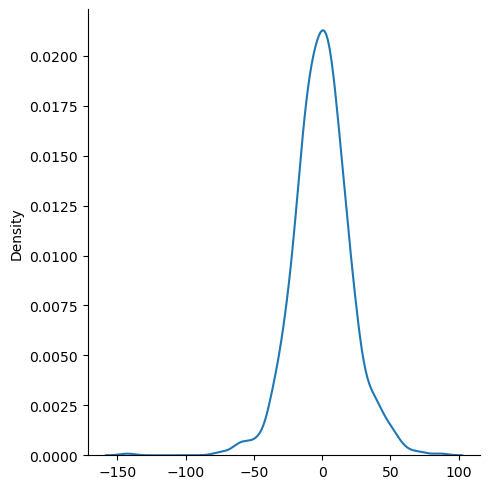

In [25]:
sns.displot(reg_pred-y_test.values, kind='kde')
plt.show()

In [26]:
from sklearn.metrics import r2_score

score = r2_score(y_test, reg_pred)

In [27]:
score

0.46563075822309863

## Model 2 — Random Forest Regressor

Random Forest with 100 estimators and 10-fold cross validation.

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(x_train, y_train)

rfr_mse = cross_val_score(rfr, x_train, y_train, scoring='neg_mean_squared_error', cv=10)

In [29]:
np.mean(rfr_mse)

np.float64(-357.6549741082007)

In [30]:
rfr_pred = rfr.predict(x_test)

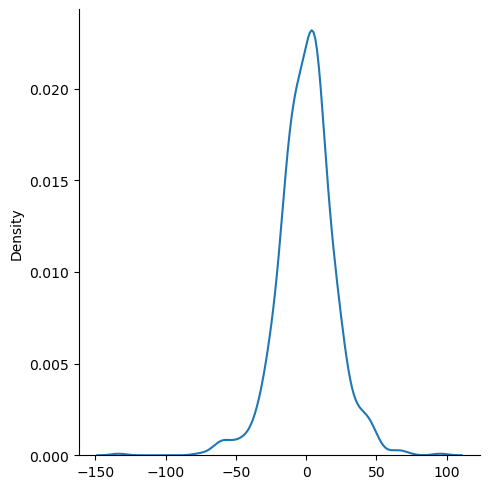

In [31]:
sns.displot(rfr_pred-y_test.values, kind='kde')
plt.show()

In [32]:
rfr_score = r2_score(y_test, rfr_pred)
rfr_score

0.5131252307009857

## Model 3 — Gradient Boosting Regressor

Gradient Boosting with 100 estimators and 10-fold cross validation.

In [33]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(x_train, y_train)

gb_mse = cross_val_score(gb, x_train, y_train, scoring='neg_mean_squared_error', cv=10)

gb_pred = gb.predict(x_test)
r2_score(y_test, gb_pred)

0.5062971317887867

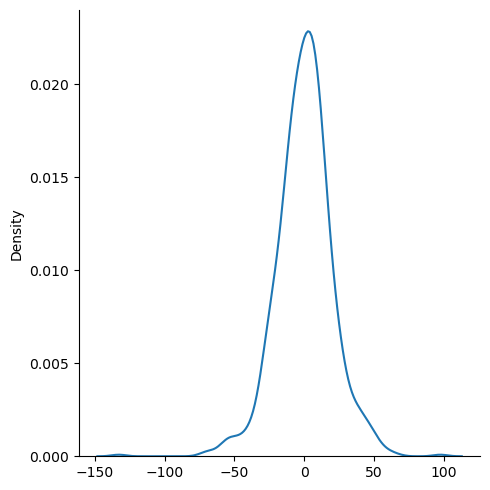

In [35]:
sns.displot(gb_pred-y_test.values, kind='kde')
plt.show()

## Feature Importance Analysis

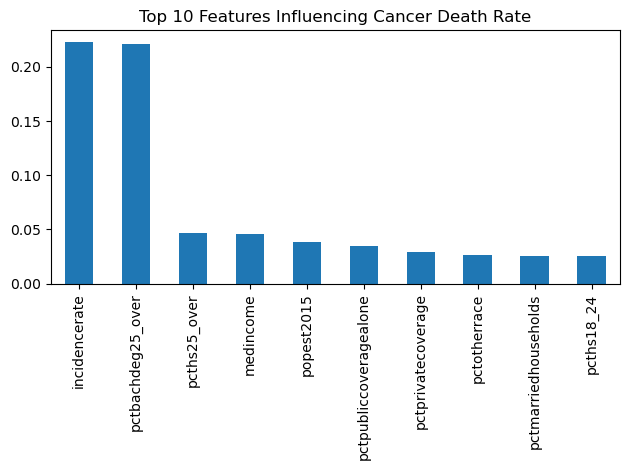

In [36]:
importances = pd.Series(rfr.feature_importances_, index=x.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Features Influencing Cancer Death Rate')
plt.tight_layout()
plt.show()

## Results Summary

| Model | R2 Score |
|---|---|
| Linear Regression | 0.466 |
| Random Forest | 0.513 |
| Gradient Boosting | 0.506 |

## Key Findings

Feature importance analysis revealed that cancer death rates are most strongly influenced by:

1. **Cancer incidence rate** — direct medical factor, higher incidence leads to higher mortality
2. **Education levels** (`pctbachdeg25_over`, `pcths25_over`) — socioeconomic factor, higher education correlates with lower death rates due to better healthcare access and earlier detection
3. **Median income** — economic factor, wealthier counties show significantly lower cancer mortality

This suggests that **social determinants of health — education and income — play an equally significant role as medical factors in cancer mortality outcomes.** Interventions targeting education and poverty may be as impactful as medical ones in reducing cancer deaths.